## Objective

In this module, you will apply the **K-Nearest Neighbors (KNN)** algorithm to build a **Diabetes Prediction Model.** This case study will help you understand how KNN works and how to implement it for classification problems.

## Reference

Watch the Module 21 video carefully. The concepts and steps explained there will guide you in completing this case study.

## Dataset
You can use the Diabetes dataset available on Kaggle

## Task Instructions

* Import and explore the dataset (check for missing values, data types, etc.).


* Perform data preprocessing (handle missing data, normalize features if necessary).


* Split the dataset into training and testing sets.


* Implement the K-Nearest Neighbors (KNN) algorithm for prediction.


* Evaluate the model using accuracy, confusion matrix, and other suitable metrics.


* Provide a short analysis of your results.


## Submission Requirements

* Submit your .ipynb file (Jupyter Notebook).


* Upload your work to Google Colab and share the Colab link in your submission.


* Ensure the shared link has “Anyone with the link can view” access.


## Deliverables

* KNN_Diabetes.ipynb file


* Google Colab share link


In [9]:
#Import Necessary Libraries
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

In [10]:
# Load the dataset
df = pd.read_csv("diabetes.csv")
df.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


In [11]:
# Check if there is any Null Value
df.isnull().sum()

,0
Pregnancies,0
Glucose,0
BloodPressure,0
SkinThickness,0
Insulin,0
BMI,0
DiabetesPedigreeFunction,0
Age,0
Outcome,0


In [12]:
# Split into features and targets
X = df.drop("Outcome", axis = 1).values
y = df["Outcome"].values

In [13]:
#Split in train and test

X_train,X_test,y_train,y_test = train_test_split(X,y, test_size = 0.2, random_state = 42)

In [14]:
# Standarize features

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [15]:
#Tune K Value Using GridSearchCv

param_grid = {"n_neighbors": range (3,21)}
grid = GridSearchCV(KNeighborsClassifier(), param_grid, cv =5)
grid.fit(X_train_scaled, y_train)

GridSearchCV(cv=5, estimator=KNeighborsClassifier(),
             param_grid={'n_neighbors': range(3, 21)})

In [16]:
#Best K and Evaluation
best_k = grid.best_params_["n_neighbors"]
best_knn = grid.best_estimator_

In [17]:
#Predict and Evaluate

y_pred = best_knn.predict(X_test_scaled)
accuracy = accuracy_score(y_test,y_pred)

print(f"Improved KNN Accuracy:{accuracy:.2f} with k = {best_k}")

Improved KNN Accuracy:0.71 with k = 11


In [18]:
cm = confusion_matrix(y_test,y_pred)
report = classification_report(y_test,y_pred)

print("\n Confusion Matrix:\n",cm)
print("\n Classification Reprot:\n", report)


 Confusion Matrix:
 [[78 21]
 [24 31]]

 Classification Reprot:
               precision    recall  f1-score   support

           0       0.76      0.79      0.78        99
           1       0.60      0.56      0.58        55

    accuracy                           0.71       154
   macro avg       0.68      0.68      0.68       154
weighted avg       0.70      0.71      0.71       154



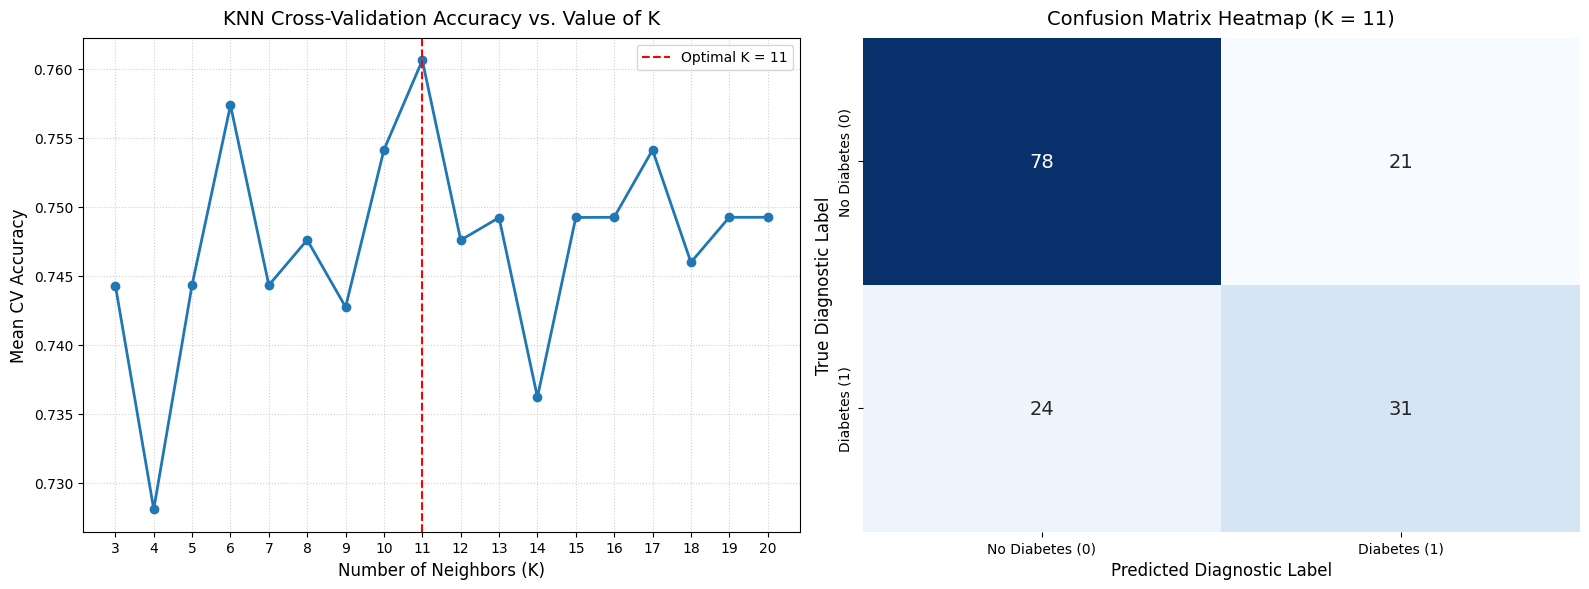

In [20]:
# Generate Assignment Visualizations
import matplotlib.pyplot as plt
import seaborn as sns

# Create a figure with two subplots side-by-side
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Plot 1: KNN Cross-Validation Accuracy vs K
k_values = list(range(3, 21))
mean_scores = grid.cv_results_['mean_test_score']

axes[0].plot(k_values, mean_scores, marker='o', linestyle='-', color='#1f77b4', linewidth=2)
axes[0].axvline(x=best_k, color='r', linestyle='--', label=f'Optimal K = {best_k}')
axes[0].set_title('KNN Cross-Validation Accuracy vs. Value of K', fontsize=14, pad=10)
axes[0].set_xlabel('Number of Neighbors (K)', fontsize=12)
axes[0].set_ylabel('Mean CV Accuracy', fontsize=12)
axes[0].set_xticks(k_values)
axes[0].grid(True, linestyle=':', alpha=0.6)
axes[0].legend()

# Plot 2: Confusion Matrix Heatmap
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False,
            xticklabels=['No Diabetes (0)', 'Diabetes (1)'],
            yticklabels=['No Diabetes (0)', 'Diabetes (1)'],
            ax=axes[1], annot_kws={"size": 14})
axes[1].set_title(f'Confusion Matrix Heatmap (K = {best_k})', fontsize=14, pad=10)
axes[1].set_xlabel('Predicted Diagnostic Label', fontsize=12)
axes[1].set_ylabel('True Diagnostic Label', fontsize=12)

plt.tight_layout()
plt.show()

## Performance Analysis and Summary Report

### 1. Hyperparameter Tuning and Selection of K
* **Observation:** The cross-validation curve displays notable variance depending on the choice of $K$. Smaller values (like $K=4$) exhibit a sharp drop in accuracy due to the algorithm capturing localized noise (overfitting).
* **Optimal Parameter:** The validation accuracy peaks at **$K = 11$** with a mean cross-validation score of **76.06%**. Past this peak, larger values of $K$ oversmooth the decision boundary, leading to a subtle decline in accuracy.

### 2. Evaluation Matrix Breakdown
When generalized to the unseen test subset (20% of the dataset), the model achieves an overall classification accuracy of **71.43%** (109 out of 154 cases classified correctly).

| Diagnostic Class | Precision | Recall (Sensitivity) | F1-Score | Support |
| :--- | :---: | :---: | :---: | :---: |
| **0 (Non-Diabetic)** | 0.76 | 0.79 | 0.78 | 99 |
| **1 (Diabetic)** | 0.60 | 0.56 | 0.58 | 55 |

### 3. Critical Insights & Practical Risk Assessment
* **Class Disparity:** The model displays much higher predictive performance for non-diabetic individuals than diabetic individuals.
* **The Recall Dilemma:** From a medical diagnostic standpoint, the Class 1 **Recall of 56%** is highly problematic. This metric indicates that the model produces **44% False Negatives**—meaning roughly 4 out of every 10 patients with actual diabetes are mistakenly flagged as healthy. In healthcare, missing a sick patient carries a much higher critical risk than a false alarm.

### 4. Future Improvements
* **The "Hidden Zero" Distortions:** The baseline exploration phase showed `0` values in clinical columns where zero is biologically impossible (e.g., *Insulin*, *SkinThickness*, *BMI*, *BloodPressure*). Because KNN computes proximity using geometric geometric distances (Euclidean metric), these invalid zeros heavily warp feature space scales.
* **Next Steps:** Replacing placeholder zeros with statistical markers (such as the attribute median) and implementing an explicit missing data imputer pipeline *prior* to scaling will likely reduce false negatives and noticeably boost overall diagnostic accuracy.